# Comparativa Conti ↔ Black Basta — Similitud semántica entre operadores

Compara los estilos de comunicación de los operadores de ambos grupos usando  
los embeddings generados en los módulos 03 de cada uno.

**Fundamento**: ambos datasets se embebieron con `nomic-embed-text-v2-moe` →  
los vectores viven en el mismo espacio de 768 dimensiones → la similitud coseno  
entre actores de distintos grupos es matemáticamente comparable.

**Qué significa similitud alta**: mismo estilo de comunicación y vocabulario.  
Puede indicar roles funcionalmente equivalentes, cultura operacional compartida  
o, especulativamente, conexión entre individuos — pero no lo prueba.

Requiere haber ejecutado `ContiLeaks/notebooks/03` y `BlackBasta/notebooks/03`.

## 0. Setup

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import umap
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

BASE = Path('..') 

CONTI_EMB      = BASE / 'ContiLeaks/data/processed/message_embeddings.npy'
CONTI_SAMPLE   = BASE / 'ContiLeaks/data/processed/conti_sample_with_embeddings.parquet'
CONTI_PROFILES = BASE / 'ContiLeaks/data/processed/actor_profiles.json'

BB_EMB         = BASE / 'BlackBasta/data/processed/bb_message_embeddings.npy'
BB_SAMPLE      = BASE / 'BlackBasta/data/processed/bb_sample_with_embeddings.parquet'
BB_PROFILES    = BASE / 'BlackBasta/data/processed/bb_actor_profiles.json'

for p in [CONTI_EMB, CONTI_SAMPLE, CONTI_PROFILES, BB_EMB, BB_SAMPLE, BB_PROFILES]:
    assert p.exists(), f'Falta: {p}'

conti_emb  = np.load(CONTI_EMB)
bb_emb     = np.load(BB_EMB)
conti_msgs = pd.read_parquet(CONTI_SAMPLE)
bb_msgs    = pd.read_parquet(BB_SAMPLE)

with open(CONTI_PROFILES)  as f: conti_profiles = json.load(f)
with open(BB_PROFILES)     as f: bb_profiles    = json.load(f)

print(f'Conti  : {conti_emb.shape[0]:,} mensajes, {conti_msgs.username.nunique()} actores, {conti_emb.shape[1]}D')
print(f'BB     : {bb_emb.shape[0]:,} mensajes, {bb_msgs.username.nunique()} actores, {bb_emb.shape[1]}D')
print('Setup OK')

Conti  : 1,500 mensajes, 30 actores, 768D
BB     : 3,598 mensajes, 47 actores, 768D
Setup OK


## 1. Centroides de actores

Para cada actor: media de todos sus embeddings de mensaje, normalizada a norma 1.  
El centroide normalizado es equivalente a la dirección semántica media del actor.

In [7]:
def compute_centroids(msgs_df: pd.DataFrame, embeddings: np.ndarray,
                      actor_col: str = 'username') -> dict[str, np.ndarray]:
    """Calcula centroide L2-normalizado por actor."""
    assert len(msgs_df) == len(embeddings), 'Mensajes y embeddings no alineados'
    centroids = {}
    for actor, group in msgs_df.groupby(actor_col):
        vecs = embeddings[group.index.tolist()]
        c = vecs.mean(axis=0)
        c /= np.linalg.norm(c)
        centroids[actor] = c
    return centroids

# Importante: reset_index para que los índices sean posicionales (0..N)
conti_msgs_r = conti_msgs.reset_index(drop=True)
bb_msgs_r    = bb_msgs.reset_index(drop=True)

conti_centroids = compute_centroids(conti_msgs_r, conti_emb)
bb_centroids    = compute_centroids(bb_msgs_r,    bb_emb)

print(f'Centroides Conti : {len(conti_centroids)} actores')
print(f'Centroides BB    : {len(bb_centroids)} actores')

Centroides Conti : 30 actores
Centroides BB    : 47 actores


## 2. Matriz de similitud cruzada (Conti × BB)

In [8]:
conti_actors = sorted(conti_centroids.keys())
bb_actors    = sorted(bb_centroids.keys())

C = np.array([conti_centroids[a] for a in conti_actors])
B = np.array([bb_centroids[a]    for a in bb_actors])

sim_matrix = cosine_similarity(C, B)  # shape: (n_conti, n_bb)

print(f'Matriz de similitud: {sim_matrix.shape}  ({sim_matrix.shape[0]} Conti × {sim_matrix.shape[1]} BB)')
print(f'  Mín: {sim_matrix.min():.3f}  Máx: {sim_matrix.max():.3f}  Media: {sim_matrix.mean():.3f}')

Matriz de similitud: (30, 47)  (30 Conti × 47 BB)
  Mín: 0.418  Máx: 0.930  Media: 0.789


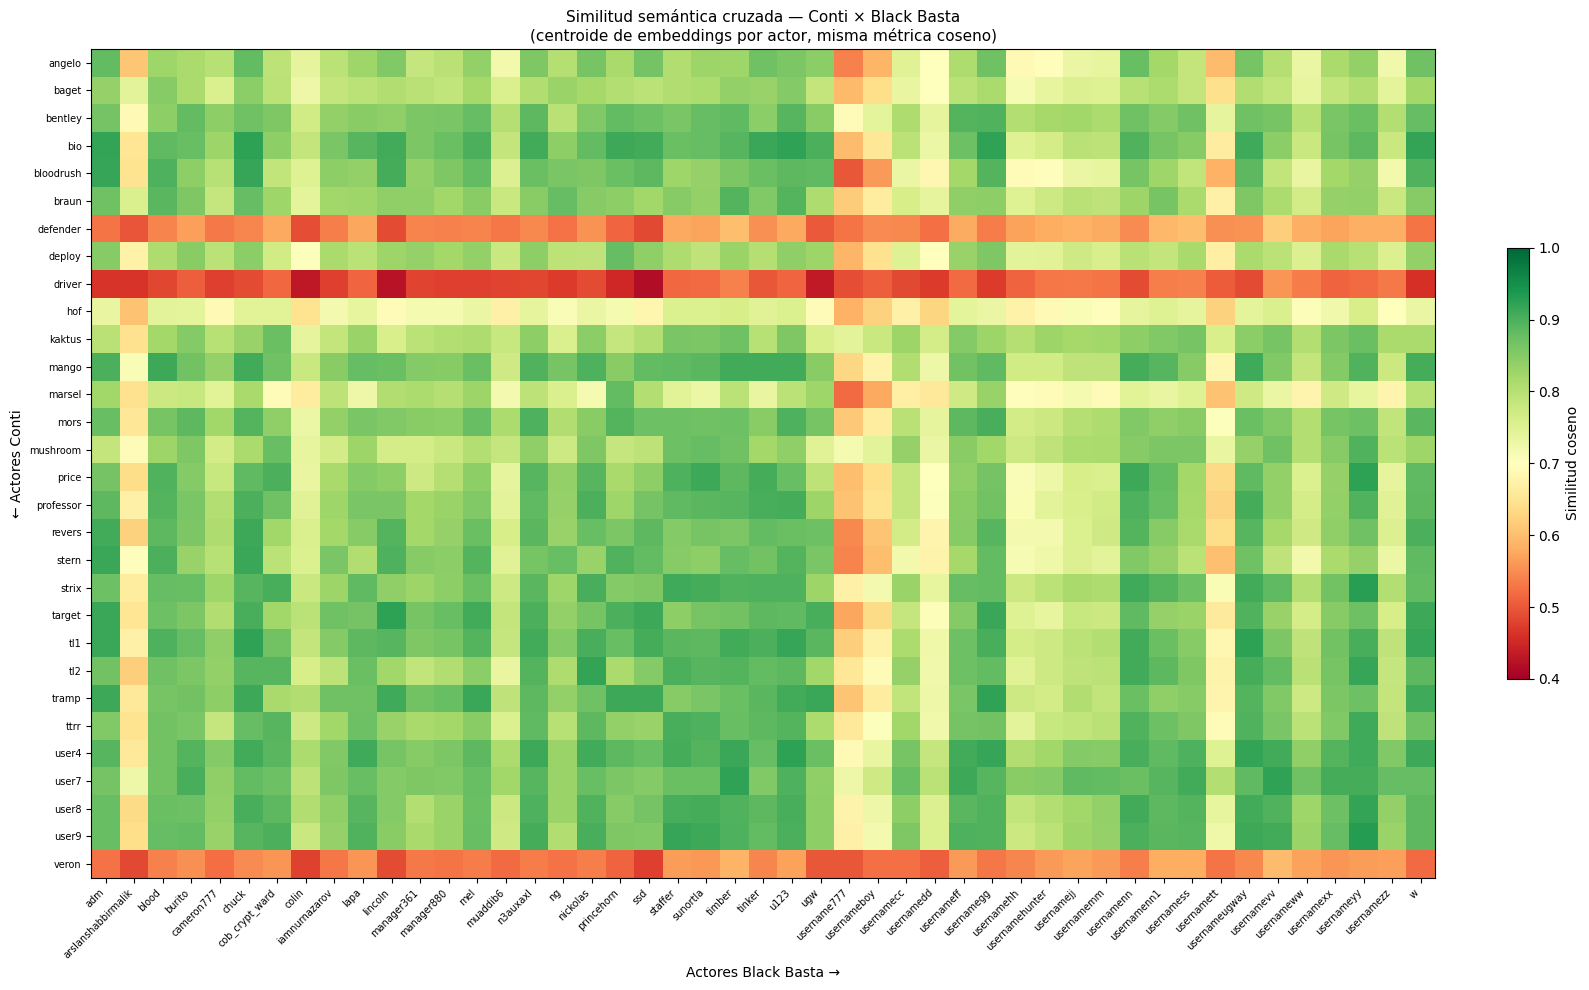

In [9]:
# Heatmap completo Conti × BB
fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(bb_actors)))
ax.set_xticklabels(bb_actors, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(conti_actors)))
ax.set_yticklabels(conti_actors, fontsize=7)

ax.set_xlabel('Actores Black Basta →', fontsize=10)
ax.set_ylabel('← Actores Conti', fontsize=10)
ax.set_title('Similitud semántica cruzada — Conti × Black Basta\n(centroide de embeddings por actor, misma métrica coseno)', fontsize=11)

plt.colorbar(im, ax=ax, fraction=0.015, label='Similitud coseno')
plt.tight_layout()
plt.show()

## 3. Top pares más similares entre grupos

In [10]:
# Extraer todos los pares con su similitud
pairs = []
for i, ca in enumerate(conti_actors):
    for j, ba in enumerate(bb_actors):
        pairs.append({
            'conti_actor': ca,
            'bb_actor':    ba,
            'similarity':  sim_matrix[i, j],
            'conti_role':  conti_profiles.get(ca, {}).get('role', '?'),
            'bb_role':     bb_profiles.get(ba,    {}).get('role', '?'),
            'conti_conf':  conti_profiles.get(ca, {}).get('confidence', '?'),
            'bb_conf':     bb_profiles.get(ba,    {}).get('confidence', '?'),
        })

pairs_df = pd.DataFrame(pairs).sort_values('similarity', ascending=False)

top20 = (pairs_df.head(20)[['conti_actor','conti_role','bb_actor','bb_role','similarity']]
         .reset_index(drop=True))
top20['similarity'] = top20['similarity'].round(3)

print('=== TOP 20 PARES MÁS SIMILARES ENTRE GRUPOS ===')
display(top20)

=== TOP 20 PARES MÁS SIMILARES ENTRE GRUPOS ===


,conti_actor,conti_role,bb_actor,bb_role,similarity
0,user9,operator,usernameyy,operator,0.930
1,strix,operator,usernameyy,operator,0.929
2,target,operator,lincoln,operator,0.925
3,bio,operator,chuck,operator,0.924
4,user4,operator,u123,operator,0.924
5,price,operator,usernameyy,operator,0.924
6,tl1,operator,usernameugway,operator,0.923
7,tl1,operator,chuck,operator,0.922
8,user7,operator,usernamevv,operator,0.922
9,bio,operator,usernamegg,operator,0.922


In [11]:
# ¿Los roles más similares coinciden entre grupos?
print('=== SIMILITUD MEDIA POR COMBINACIÓN DE ROLES ===')
role_sim = (pairs_df
            .groupby(['conti_role', 'bb_role'])['similarity']
            .agg(['mean', 'count'])
            .round(3)
            .sort_values('mean', ascending=False)
            .reset_index())
display(role_sim.head(15))

=== SIMILITUD MEDIA POR COMBINACIÓN DE ROLES ===


,conti_role,bb_role,mean,count
0,developer,unknown,0.849,6
1,operator,unknown,0.847,22
2,operator,developer,0.831,88
3,developer,developer,0.818,24
4,operator,operator,0.810,814
5,developer,operator,0.801,222
6,operator,support,0.765,110
7,developer,support,0.762,30
8,support,operator,0.548,74
9,support,unknown,0.546,2


In [12]:
# Mostrar mensajes representativos del par más similar
top_pair = pairs_df.iloc[0]
print(f'Par más similar: [{top_pair.conti_actor} / Conti] ↔ [{top_pair.bb_actor} / BB]')
print(f'Similitud: {top_pair.similarity:.3f}')
print(f'Roles: {top_pair.conti_role} ↔ {top_pair.bb_role}')
print()

print(f'--- Mensajes de {top_pair.conti_actor} (Conti) ---')
for msg in conti_msgs[conti_msgs.username == top_pair.conti_actor]['message'].head(5):
    print(f'  · {str(msg)[:120].replace(chr(10), " ")}')

print(f'\n--- Mensajes de {top_pair.bb_actor} (Black Basta) ---')
for msg in bb_msgs[bb_msgs.username == top_pair.bb_actor]['message'].head(5):
    print(f'  · {str(msg)[:120].replace(chr(10), " ")}')

Par más similar: [user9 / Conti] ↔ [usernameyy / BB]
Similitud: 0.930
Roles: operator ↔ operator

--- Mensajes de user9 (Conti) ---
  · ``` [+] received output: [+] STUPENDOUS => wendy:0204 [*] Saved TGT into wendy.kirbi  [+] received output: [+] STUPENDOU
  · Доброе
  · на комаду стараюсь)
  · у него не сменён пароль? если в 20 числах снималось ``` adm.fraste1 Password last set            23/09/2020 12:59:10 PM 
  · найти админку

--- Mensajes de usernameyy (Black Basta) ---
  · cpu 2core 2.4 ghz, 4 gb ram, 100 gb space x2
  · и я могу завтра не приезжать?
  · создайте свой грейн
  · если wmi работает то можно запускать любую прогу, в тч кобу
  · его сложно запустить


## 4. UMAP conjunto — todos los actores en el mismo espacio

Re-entrenamos UMAP solo sobre los 77 centroides (30 Conti + 47 BB).  
Al proyectar todos juntos, actores semánticamente similares quedan próximos  
independientemente del grupo al que pertenezcan.

In [13]:
all_actors  = conti_actors + bb_actors
all_vecs    = np.vstack([C, B])
group_label = ['Conti'] * len(conti_actors) + ['BlackBasta'] * len(bb_actors)
roles       = ([conti_profiles.get(a, {}).get('role', '?') for a in conti_actors] +
               [bb_profiles.get(a,    {}).get('role', '?') for a in bb_actors])

print(f'Proyectando {len(all_actors)} centroides con UMAP...')
reducer = umap.UMAP(n_neighbors=8, min_dist=0.2, metric='cosine',
                    random_state=42, n_components=2)
coords = reducer.fit_transform(all_vecs)
print('OK')

Proyectando 77 centroides con UMAP...


/home/drjekyll/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


OK


/tmp/ipykernel_183220/1264714543.py:12: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, c=color, marker=marker, s=120, alpha=0.85,


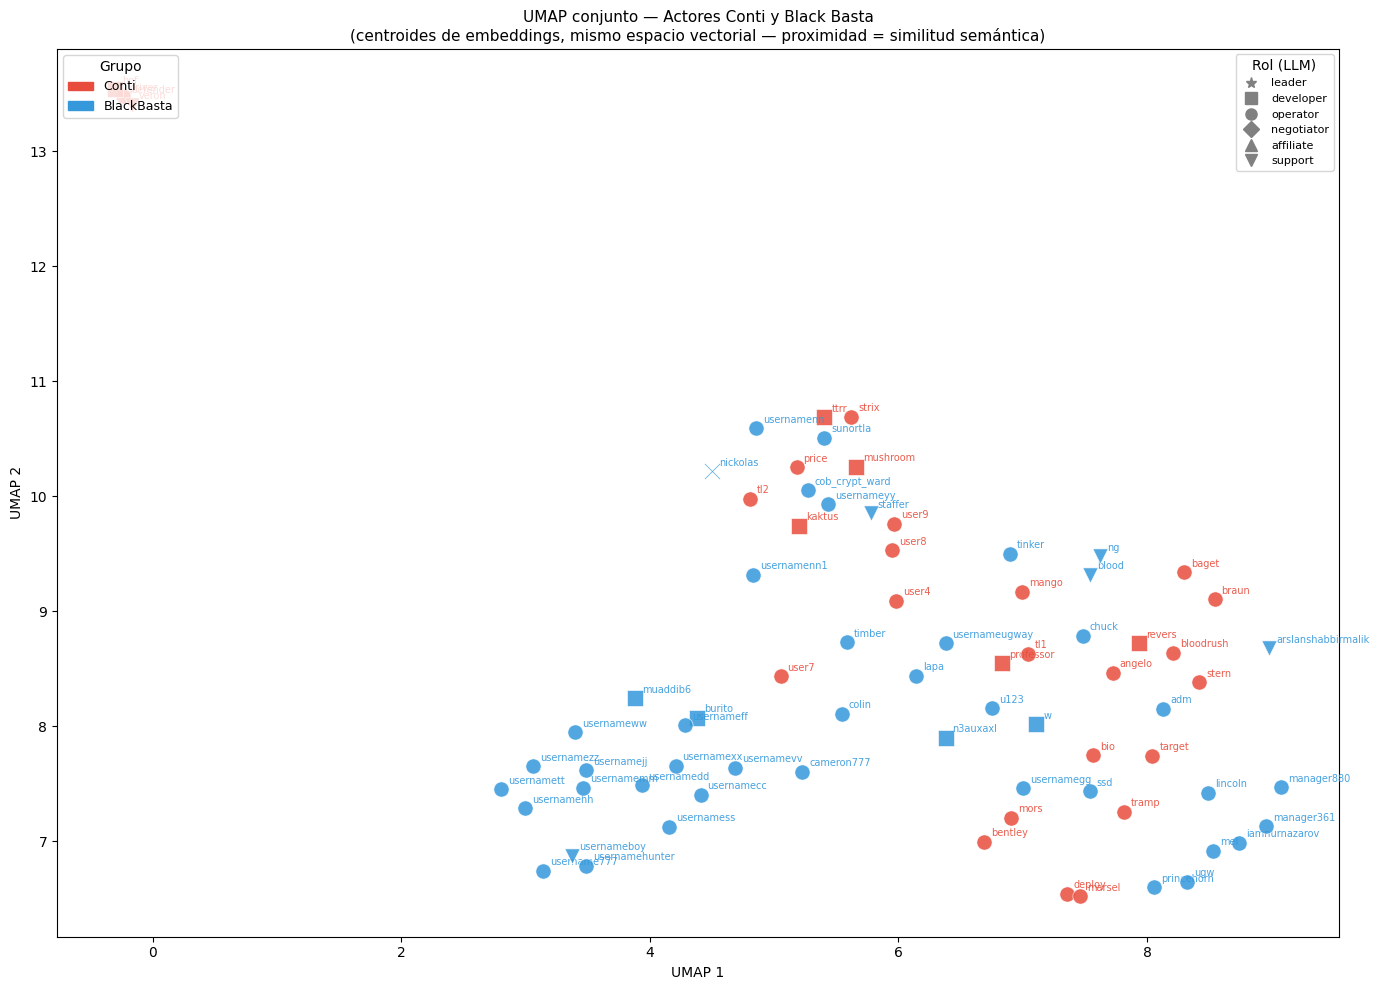

In [14]:
group_colors = {'Conti': '#e74c3c', 'BlackBasta': '#3498db'}
role_markers = {
    'leader': '*', 'developer': 's', 'operator': 'o',
    'negotiator': 'D', 'affiliate': '^', 'support': 'v', 'unknown': 'x'
}

fig, ax = plt.subplots(figsize=(14, 10))

for i, (actor, group, role, (x, y)) in enumerate(zip(all_actors, group_label, roles, coords)):
    color  = group_colors[group]
    marker = role_markers.get(role, 'o')
    ax.scatter(x, y, c=color, marker=marker, s=120, alpha=0.85,
               edgecolors='white', linewidths=0.5, zorder=3)
    ax.annotate(actor, (x, y), textcoords='offset points',
                xytext=(5, 4), fontsize=7, color=color, alpha=0.9)

# Leyenda de grupos
legend_group = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
# Leyenda de roles (markers)
from matplotlib.lines import Line2D
legend_roles = [Line2D([0],[0], marker=m, color='gray', linestyle='None',
                        markersize=8, label=r)
                for r, m in role_markers.items() if r != 'unknown']

l1 = ax.legend(handles=legend_group, title='Grupo', loc='upper left', fontsize=9)
ax.add_artist(l1)
ax.legend(handles=legend_roles, title='Rol (LLM)', loc='upper right', fontsize=8)

ax.set_title('UMAP conjunto — Actores Conti y Black Basta\n'
             '(centroides de embeddings, mismo espacio vectorial — proximidad = similitud semántica)',
             fontsize=11)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## 5. ¿Están los grupos semánticamente separados?

Si los dos grupos forman clusters distintos en el UMAP → estilos de comunicación  
diferenciados. Si se mezclan → cultura operacional compartida.

In [15]:
coords_df = pd.DataFrame({'actor': all_actors, 'group': group_label,
                           'role': roles, 'x': coords[:,0], 'y': coords[:,1]})

# Similitud media intra-grupo vs inter-grupo
n_c = len(conti_actors)
intra_conti = cosine_similarity(C).mean()
intra_bb    = cosine_similarity(B).mean()
inter       = sim_matrix.mean()

print('=== COHESIÓN SEMÁNTICA ===')
print(f'  Intra-Conti      (Conti ↔ Conti)    : {intra_conti:.3f}')
print(f'  Intra-BB         (BB ↔ BB)           : {intra_bb:.3f}')
print(f'  Inter-grupo      (Conti ↔ BB)        : {inter:.3f}')
print()
print('Interpretación:')
if intra_conti > inter and intra_bb > inter:
    print('  → Cada grupo es más cohesivo internamente que entre sí.')
    print('    Los grupos tienen estilos de comunicación diferenciados.')
elif inter > min(intra_conti, intra_bb):
    print('  → La similitud inter-grupo es comparable a la intra-grupo.')
    print('    Posible cultura operacional compartida o influencia mutua.')
else:
    print('  → Resultado mixto — revisar distribución por roles.')

=== COHESIÓN SEMÁNTICA ===
  Intra-Conti      (Conti ↔ Conti)    : 0.785
  Intra-BB         (BB ↔ BB)           : 0.832
  Inter-grupo      (Conti ↔ BB)        : 0.789

Interpretación:
  → La similitud inter-grupo es comparable a la intra-grupo.
    Posible cultura operacional compartida o influencia mutua.


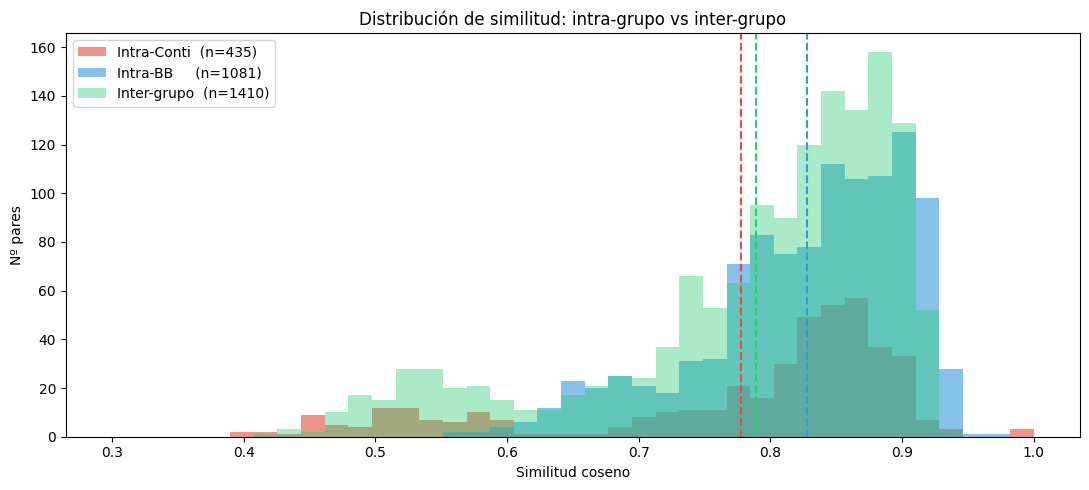

In [16]:
# Distribución de similitud: intra vs inter
intra_c_vals = cosine_similarity(C)[np.triu_indices(len(C), k=1)]
intra_b_vals = cosine_similarity(B)[np.triu_indices(len(B), k=1)]
inter_vals   = sim_matrix.flatten()

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(0.3, 1.0, 40)

ax.hist(intra_c_vals, bins=bins, alpha=0.6, color='#e74c3c', label=f'Intra-Conti  (n={len(intra_c_vals)})')
ax.hist(intra_b_vals, bins=bins, alpha=0.6, color='#3498db', label=f'Intra-BB     (n={len(intra_b_vals)})')
ax.hist(inter_vals,   bins=bins, alpha=0.4, color='#2ecc71', label=f'Inter-grupo  (n={len(inter_vals)})')

for vals, color in [(intra_c_vals,'#e74c3c'),(intra_b_vals,'#3498db'),(inter_vals,'#2ecc71')]:
    ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Similitud coseno')
ax.set_ylabel('Nº pares')
ax.set_title('Distribución de similitud: intra-grupo vs inter-grupo')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Actores con mayor similitud cruzada por rol

¿Hay roles donde la similitud inter-grupo es especialmente alta?

In [17]:
# Para cada actor Conti, su mejor par en BB y viceversa
best_bb = []
for i, ca in enumerate(conti_actors):
    j_best = sim_matrix[i].argmax()
    best_bb.append({
        'conti':       ca,
        'conti_role':  conti_profiles.get(ca, {}).get('role', '?'),
        'best_bb':     bb_actors[j_best],
        'bb_role':     bb_profiles.get(bb_actors[j_best], {}).get('role', '?'),
        'similarity':  round(float(sim_matrix[i, j_best]), 3),
    })

best_bb_df = (pd.DataFrame(best_bb)
              .sort_values('similarity', ascending=False)
              .reset_index(drop=True))

print('=== MEJOR PAR EN BB PARA CADA ACTOR CONTI (top 15) ===')
display(best_bb_df.head(15))

print()
print('Conti top 5 → resumen del perfil LLM:')
for _, row in best_bb_df.head(5).iterrows():
    summ_c = conti_profiles.get(row.conti, {}).get('summary', '')[:100]
    summ_b = bb_profiles.get(row.best_bb, {}).get('summary', '')[:100]
    print(f'  {row.conti} [{row.conti_role}]: {summ_c}')
    print(f'  {row.best_bb} [{row.bb_role}]: {summ_b}')
    print(f'  sim={row.similarity:.3f}')
    print()

=== MEJOR PAR EN BB PARA CADA ACTOR CONTI (top 15) ===


,conti,conti_role,best_bb,bb_role,similarity
0,user9,operator,usernameyy,operator,0.930
1,strix,operator,usernameyy,operator,0.929
2,target,operator,lincoln,operator,0.925
3,price,operator,usernameyy,operator,0.924
4,bio,operator,chuck,operator,0.924
5,user4,operator,u123,operator,0.924
6,tl1,operator,usernameugway,operator,0.923
7,user7,operator,usernamevv,operator,0.922
8,tramp,operator,usernamegg,operator,0.921
9,user8,operator,usernameyy,operator,0.920



Conti top 5 → resumen del perfil LLM:
  user9 [operator]: This individual is actively involved in the operational aspects of network infiltration and lateral 
  usernameyy [operator]: The individual is responsible for managing compromised systems and conducting operations such as cre
  sim=0.930

  strix [operator]: The individual appears to be an operator responsible for setting up and maintaining the ransomware i
  usernameyy [operator]: The individual is responsible for managing compromised systems and conducting operations such as cre
  sim=0.929

  target [operator]: This individual appears to be an operator within the Conti ransomware group, responsible for executi
  lincoln [operator]: Lincoln appears to be an operator involved in direct communication with victims, attempting to insta
  sim=0.925

  price [operator]: The individual appears to be an operator involved in the technical aspects of ransomware operations,
  usernameyy [operator]: The individual is responsible for man